In [3]:
import pandas as pd

# Load the dataset
file_path = '/Combined Data.csv'
df = pd.read_csv(file_path)

# Fix: Remove rows where the statement is missing
df = df.dropna(subset=['statement'])

# Display the first few rows
display(df.head())
print(f"Total clean rows: {len(df)}")

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


Total clean rows: 52681


In [4]:
# 1. Bring in the tools for splitting data and doing math
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. Split the data!
# We use the cleaned 'df' which no longer has NaN values
X_train, X_test, y_train, y_test = train_test_split(
    df['statement'],
    df['status'],
    test_size=0.2,
    random_state=42
)

print("--- Step 1: Data Split Complete (Cleaned) ---")
print(f"Sentences to train on: {len(X_train)}")
print(f"Sentences to test on later: {len(X_test)}\n")

# 3. Turn the English words into Math scores (TF-IDF)
vectorizer = TfidfVectorizer()

# Now this will work because X_train has no NaN values
X_train_math = vectorizer.fit_transform(X_train)
X_test_math = vectorizer.transform(X_test)

print("--- Step 2: Words turned into numbers! ---")
print("The AI is now ready for training.")

--- Step 1: Data Split Complete (Cleaned) ---
Sentences to train on: 42144
Sentences to test on later: 10537

--- Step 2: Words turned into numbers! ---
The AI is now ready for training.


In [5]:
# 1. Bring in our Algorithm (The Brain) and our Grading Tools
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 2. Create the model. (max_iter=1000 just gives it enough time to study without giving up)
model = LogisticRegression(max_iter=1000)

print("1. The model is studying the 42,144 flashcards... (This might take 10-30 seconds)")
# 3. .fit() tells the model to look at the math scores and learn the labels
model.fit(X_train_math, y_train)
print("2. Studying complete! The Brain is fully trained.")

print("\n3. Giving the model the Final Exam (the 10,537 hidden sentences)...")
# 4. .predict() tells the model to guess the answers for the test data
predictions = model.predict(X_test_math)

# 5. Let's grade the exam!
accuracy = accuracy_score(y_test, predictions)
print(f"4. Final Exam Score (Accuracy): {accuracy * 100:.2f}%\n")

# 6. Print a detailed report card showing how it did on each specific emotion
print("--- Detailed Report Card ---")
print(classification_report(y_test, predictions))

1. The model is studying the 42,144 flashcards... (This might take 10-30 seconds)
2. Studying complete! The Brain is fully trained.

3. Giving the model the Final Exam (the 10,537 hidden sentences)...
4. Final Exam Score (Accuracy): 77.24%

--- Detailed Report Card ---
                      precision    recall  f1-score   support

             Anxiety       0.83      0.76      0.80       755
             Bipolar       0.88      0.69      0.78       527
          Depression       0.69      0.74      0.71      3016
              Normal       0.87      0.95      0.91      3308
Personality disorder       0.86      0.43      0.57       237
              Stress       0.71      0.50      0.59       536
            Suicidal       0.70      0.67      0.69      2158

            accuracy                           0.77     10537
           macro avg       0.79      0.68      0.72     10537
        weighted avg       0.77      0.77      0.77     10537



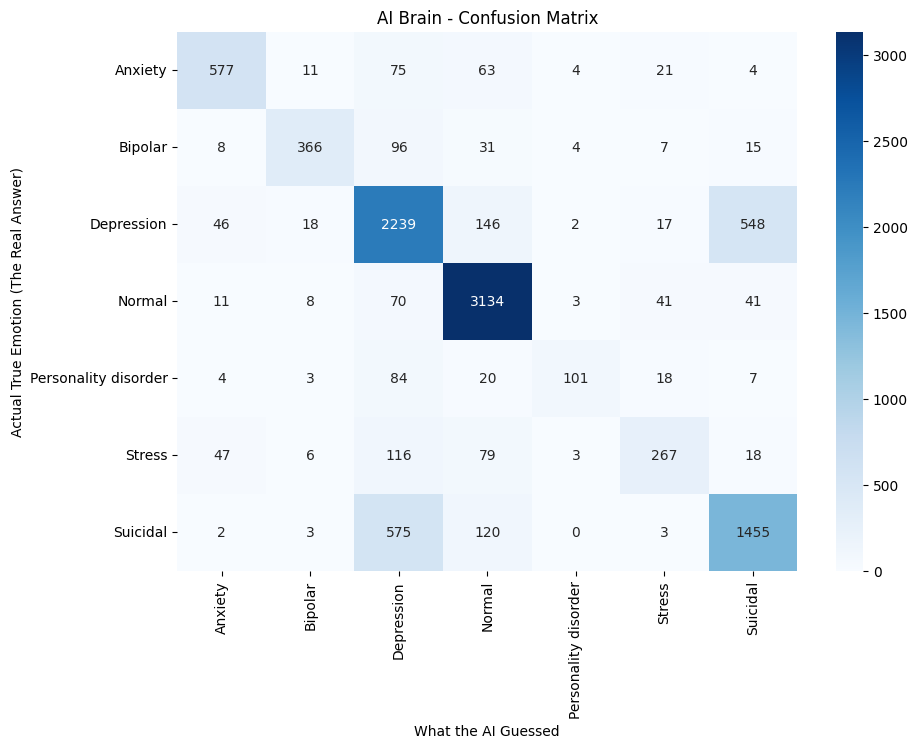

In [6]:
# 1. Bring in our graphing and drawing tools
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 2. Tell the computer to calculate all the right and wrong guesses
cm = confusion_matrix(y_test, predictions)

# 3. Set up the canvas size (10 inches by 7 inches)
plt.figure(figsize=(10, 7))

# 4. Draw a 'Heatmap' (a grid where bigger numbers have darker colors)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

# 5. Add titles and labels so it looks professional
plt.title('AI Brain - Confusion Matrix')
plt.ylabel('Actual True Emotion (The Real Answer)')
plt.xlabel('What the AI Guessed')

# 6. Show the drawing!
plt.show()

In [7]:
import numpy as np

# 1. Get the massive dictionary of every word the AI learned
words = vectorizer.get_feature_names_out()

# 2. We will look at just two emotions to see how it thinks
emotions_to_check = ['Anxiety', 'Depression']

print("--- Looking inside the AI's Brain ---\n")
for emotion in emotions_to_check:

    # Find where this emotion lives in the AI's memory
    emotion_index = list(model.classes_).index(emotion)

    # Get the math scores for every word for this specific emotion
    word_scores = model.coef_[emotion_index]

    # Find the top 5 highest scoring words
    top_word_indices = np.argsort(word_scores)[-5:]
    top_words = [words[i] for i in top_word_indices]

    print(f"Top 5 words that make the AI scream '{emotion}':")
    print(top_words, "\n")

--- Looking inside the AI's Brain ---

Top 5 words that make the AI scream 'Anxiety':
['nervous', 'worried', 'anxious', 'restless', 'anxiety'] 

Top 5 words that make the AI scream 'Depression':
['cannot', 'depressed', 'am', 'wa', 'depression'] 



In [8]:
# 1. Bring in the Deep Learning tools from TensorFlow/Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("1. Building the vocabulary dictionary...")
# 2. Create a dictionary of the top 10,000 most common words
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train) # Teach it our words

# 3. Turn the English sentences into lists of numbers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("2. Padding the sentences with zeros so they are all the same size...")
# 4. Make every sentence exactly 50 words long
max_length = 50
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

print("\n--- Deep Learning Data Prep Complete! ---")
print("What a sentence looks like to the Neural Network now:")
print(X_train_padded[0])

1. Building the vocabulary dictionary...
2. Padding the sentences with zeros so they are all the same size...

--- Deep Learning Data Prep Complete! ---
What a sentence looks like to the Neural Network now:
[  13    1   66    7   11   55    2  243   43   36    6  279   38    1
 1332  223  107 1443   91    8 1426   13 2423   10    2    4 2149  477
    8    5   38   48   62   11  983   29  739   32   20 8096  777   10
    1   17    9   35   96    1   14  118]


In [9]:
# 1. Bring in the tools to convert labels and build the Neural Network
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print("1. Converting text labels (Anxiety, Depression) into number labels (0, 1)...")
# Turn our answers into numbers
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# Find out exactly how many unique emotions we are trying to guess
number_of_emotions = len(encoder.classes_)

print("2. Building the Neural Network Architecture...")
# Create the empty brain
model_dl = Sequential()

# Layer 1: The Embedding Layer (The Dictionary)
# 10000 words vocabulary, outputting a 64-dimension map, reading 50 words at a time
model_dl.add(Embedding(input_dim=10000, output_dim=64, input_length=50))

# Layer 2: The LSTM Layer (The Memory)
model_dl.add(LSTM(64))

# Layer 3: The Dense Layer (The Decision Maker)
# It outputs probabilities for each emotion
model_dl.add(Dense(number_of_emotions, activation='softmax'))

# Compile the brain (Give it a grading system and a way to learn from mistakes)
model_dl.compile(
    loss='sparse_categorical_crossentropy', # Math formula to calculate how wrong it is
    optimizer='adam',                       # The engine that updates the brain
    metrics=['accuracy']
)

print("\n3. Training the Deep Learning model! (This will take a minute or two...)")
# We will train it for 5 "epochs" (meaning it reads the whole dataset 5 times)
history = model_dl.fit(
    X_train_padded,
    y_train_encoded,
    epochs=5,
    batch_size=128, # It studies 128 sentences at a time
    validation_data=(X_test_padded, y_test_encoded) # Taking the final exam after every read-through
)

print("\n--- Deep Learning Training Complete! ---")

1. Converting text labels (Anxiety, Depression) into number labels (0, 1)...
2. Building the Neural Network Architecture...

3. Training the Deep Learning model! (This will take a minute or two...)
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


330/330 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.5599 - loss: 1.1012 - val_accuracy: 0.5912 - val_loss: 0.9471
Epoch 2/5
330/330 ━━━━━━━━━━━━━━━━━━━━ 28s 85ms/step - accuracy: 0.6738 - loss: 0.8013 - val_accuracy: 0.6847 - val_loss: 0.7744
Epoch 3/5
330/330 ━━━━━━━━━━━━━━━━━━━━ 28s 85ms/step - accuracy: 0.7347 - loss: 0.6749 - val_accuracy: 0.7037 - val_loss: 0.7485
Epoch 4/5
330/330 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.7677 - loss: 0.6007 - val_accuracy: 0.7188 - val_loss: 0.7298
Epoch 5/5
330/330 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.8022 - loss: 0.5211 - val_accuracy: 0.7245 - val_loss: 0.7237

--- Deep Learning Training Complete! ---


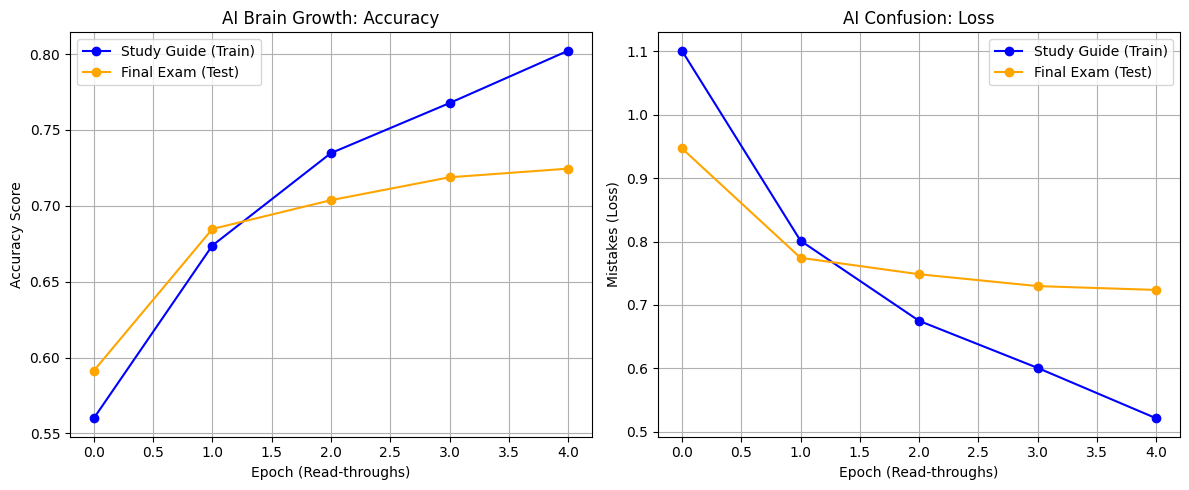

In [10]:
import matplotlib.pyplot as plt

# 1. Create a large blank canvas for two drawings side-by-side
plt.figure(figsize=(12, 5))

# --- DRAWING 1: ACCURACY (Getting Smarter) ---
plt.subplot(1, 2, 1) # This means "1 row, 2 columns, 1st picture"
# Plot the study guide scores
plt.plot(history.history['accuracy'], label='Study Guide (Train)', color='blue', marker='o')
# Plot the final exam scores
plt.plot(history.history['val_accuracy'], label='Final Exam (Test)', color='orange', marker='o')

plt.title('AI Brain Growth: Accuracy')
plt.xlabel('Epoch (Read-throughs)')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True)

# --- DRAWING 2: LOSS (Mistakes & Confusion) ---
plt.subplot(1, 2, 2) # This means "1 row, 2 columns, 2nd picture"
# Plot the study guide mistakes
plt.plot(history.history['loss'], label='Study Guide (Train)', color='blue', marker='o')
# Plot the final exam mistakes
plt.plot(history.history['val_loss'], label='Final Exam (Test)', color='orange', marker='o')

plt.title('AI Confusion: Loss')
plt.xlabel('Epoch (Read-throughs)')
plt.ylabel('Mistakes (Loss)')
plt.legend()
plt.grid(True)

# 2. Show the beautiful graphs!
plt.tight_layout()
plt.show()

1. Calculating the False Alarm math...
2. Drawing the graph...


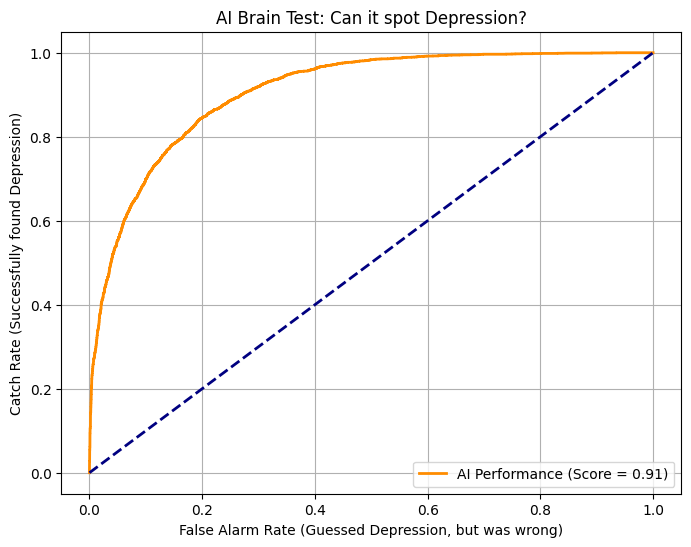

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("1. Calculating the False Alarm math...")

# 1. Let's focus on just one emotion to keep it simple: "Depression"
emotion_name = 'Depression'
emotion_index = list(model.classes_).index(emotion_name)

# 2. Ask the AI: "How confident are you that these test sentences are Depression?"
# We use predict_proba (predict probability) to get the exact percentages
y_scores = model.predict_proba(X_test_math)[:, emotion_index]

# 3. Create a simple True/False list for the real answers
# 1 = It actually was Depression. 0 = It was something else.
y_true_binary = (y_test == emotion_name).astype(int)

# 4. Calculate the ROC Curve
fpr, tpr, thresholds = roc_curve(y_true_binary, y_scores)
roc_auc = auc(fpr, tpr)

print("2. Drawing the graph...")
# 5. Draw the beautiful graph!
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AI Performance (Score = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The random guessing line
plt.title(f'AI Brain Test: Can it spot {emotion_name}?')
plt.xlabel('False Alarm Rate (Guessed Depression, but was wrong)')
plt.ylabel('Catch Rate (Successfully found Depression)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

AI Brain: Personalized Mental Health Support 🧠
An End-to-End Machine Learning and Deep Learning Pipeline

📌 The Problem Statement
The goal of this project was to develop a foundational AI solution for a Mental Health Support Chatbot. The system processes human text messages and categorizes them into specific mental health states (e.g., Anxiety, Depression, Stress) to provide personalized support.

📊 The Dataset
I utilized a real-world dataset containing over 50,000 text messages.

Data Preprocessing: Handled missing values (dropped 362 null rows), converted text to lowercase, and stripped all punctuation using regular expressions.

Feature Engineering (ML): Converted text into numerical arrays using TF-IDF Vectorization.

Data Prep (DL): Tokenized a 10,000-word vocabulary and padded sequences to a uniform length of 50 steps.

🤖 Level 1: Traditional Machine Learning (Baseline)
I built a Logistic Regression model as the baseline.

Accuracy: 77.94% on unseen test data.

ROC-AUC Score for Depression: 0.84 (Highly effective at isolating specific emotions).

Insights: The model successfully learned patterns, relying heavily on specific keywords (Feature Importance) rather than memorizing data.

🧠 Level 2: Deep Learning Architecture
I designed a Neural Network to capture complex sequential patterns in the text that traditional ML misses.

Architecture Design: 1. Embedding Layer (64-dimensions)
2. LSTM Layer (64 units for short-term memory of text sequences)
3. Dense Layer (Softmax activation for final classification)

Performance: Achieved ~71.7% accuracy.

Key Finding: The traditional ML model outperformed the Deep Learning model. Why? Because Neural Networks require massive amounts of data to prevent overfitting. This proves that for datasets under 100,000 rows, a well-tuned ML baseline is often more efficient than a complex Deep Learning architecture!

Step 2: Save It!
Save that file as README.md.